# Notebook 04 – Machine Learning

## Customer Churn Prediction

This notebook develops machine learning models to predict customer churn and identify the customer characteristics that provide the strongest predictive signals.

### Objectives

- Prepare features for machine learning
- Define the target variable
- Encode categorical variables
- Split the dataset into training and testing sets
- Establish a baseline model
- Train classification models
- Evaluate model performance
- Compare models
- Identify important churn predictors
- Translate model results into business insights

## 1. Load Processed Data

The cleaned and validated dataset generated during the data cleaning stage is loaded for machine learning preparation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

df.shape

(7043, 21)

In [5]:
(7043, 21)

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Define Target Variable and Features

The target variable for this classification problem is `Churn`.

The `customerID` column is an identifier and will be excluded from model features because it does not represent a meaningful customer characteristic.

All remaining variables will be considered candidate predictors.

In [7]:
target = "Churn"

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X.shape, y.shape

((7043, 19), (7043,))

## 3. Encode Target Variable

The `Churn` target is converted from categorical labels to binary numeric values for classification modeling.

- `No` → 0
- `Yes` → 1

In [8]:
y = y.map({
    "No": 0,
    "Yes": 1
})

y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## 4. Train/Test Split

The dataset is divided into training and testing sets using an 80/20 split.

Stratification is applied to the target variable to preserve the original churn distribution in both datasets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [10]:
y_train.value_counts(normalize=True).mul(100).round(2)

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

In [11]:
y_test.value_counts(normalize=True).mul(100).round(2)

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

## 5. Feature Preprocessing

Categorical features are converted into numerical representations using One-Hot Encoding.

Numeric features are retained in their original form.

A ColumnTransformer is used to apply the appropriate preprocessing to each feature type while keeping the preprocessing steps within the machine learning workflow.

In [12]:
categorical_features = X.select_dtypes(include=["str"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["str"]).columns.tolist()

categorical_features, numeric_features

(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'])

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [15]:
X_train_processed.shape, X_test_processed.shape

((5634, 45), (1409, 45))

## 6. Baseline Model

A majority-class baseline is established before training machine learning models.

The baseline predicts the majority class (`No Churn`) for every customer.

This provides a simple reference point against which the performance of machine learning models can be evaluated.

In [16]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train_processed, y_train)

baseline_accuracy = baseline_model.score(
    X_test_processed,
    y_test
)

baseline_accuracy

0.7345635202271115

### Baseline Result

The majority-class baseline achieves an accuracy of **73.46%** by predicting **No Churn** for every customer.

This establishes the minimum benchmark that subsequent machine learning models should improve upon.

However, accuracy alone is not sufficient for evaluating churn prediction because the target variable is imbalanced. **Precision, Recall, F1-score, and ROC-AUC** will therefore be considered during model evaluation.

## 7. Logistic Regression

Logistic Regression is used as the first predictive classification model.

The model estimates the probability that a customer will churn based on the available customer, account, service, and billing characteristics.

In [17]:
logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

In [19]:
y_pred = logistic_model.predict(X_test_processed)

y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8062
Precision: 0.6583
Recall   : 0.5615
F1-Score : 0.6061
ROC-AUC  : 0.8423


In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [164 210]]


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [23]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
y_pred_tree = decision_tree.predict(X_test_processed)

y_pred_tree_proba = decision_tree.predict_proba(
    X_test_processed
)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [25]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_pred_tree_proba)

print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1-Score : {f1_tree:.4f}")
print(f"ROC-AUC  : {roc_auc_tree:.4f}")

Accuracy : 0.7225
Precision: 0.4781
Recall   : 0.4973
F1-Score : 0.4875
ROC-AUC  : 0.6504


In [26]:
DecisionTreeClassifier(random_state=42)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [27]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print(cm_tree)

[[832 203]
 [188 186]]


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees.

Unlike a single Decision Tree, which can easily overfit the training data, Random Forest builds multiple trees using different samples and subsets of features and combines their predictions.

For this baseline model, 100 decision trees are used without hyperparameter tuning. The model's performance will be compared with Logistic Regression and Decision Tree using the same evaluation metrics.

In [28]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

random_forest.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### Generate Predictions

The trained Random Forest model is used to generate class predictions and churn probabilities on the test dataset.

- `y_pred_rf` contains the predicted churn class (0 or 1).
- `y_pred_rf_proba` contains the predicted probability of churn and will be used to calculate ROC-AUC.

In [29]:
y_pred_rf = random_forest.predict(X_test_processed)

y_pred_rf_proba = random_forest.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


### Model Evaluation

The Random Forest model is evaluated on the test dataset using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Since customer churn is an imbalanced classification problem, particular attention is given to **Recall** and **ROC-AUC**, as identifying customers who are likely to churn is an important business objective.

In [30]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_rf_proba)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.7885
Precision: 0.6301
Recall   : 0.4920
F1-Score : 0.5526
ROC-AUC  : 0.8166


### Random Forest Performance Interpretation

The baseline Random Forest achieved an accuracy of **78.85%** and a ROC-AUC score of **0.8166**, showing considerably stronger predictive performance than the baseline Decision Tree.

However, Logistic Regression remains the strongest baseline model, outperforming Random Forest across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The Random Forest recall of **49.20%** indicates that approximately half of the actual churners are correctly identified at the default classification threshold. Since detecting potential churners is an important business objective, improving recall will be considered during later model tuning and threshold optimization.

### Confusion Matrix

The confusion matrix provides a detailed view of the Random Forest classification results by showing the number of correct and incorrect predictions for both churn and non-churn customers.

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[927 108]
 [190 184]]


### Confusion Matrix Interpretation

The Random Forest correctly classified **927 non-churners** and **184 churners**.

However, **190 actual churners were incorrectly classified as non-churners (False Negatives)**. This explains the model's relatively low churn recall of **49.20%**.

Compared with Logistic Regression, Random Forest produces slightly fewer False Positives but substantially more False Negatives. Since failing to identify customers who are likely to churn may result in missed retention opportunities, Logistic Regression currently remains the stronger baseline model.

## Gradient Boosting Classifier

Gradient Boosting is an ensemble learning technique that builds multiple decision trees sequentially.

Unlike Random Forest, where trees are built largely independently, Gradient Boosting builds each new tree to correct errors made by the previous trees. This sequential learning process can capture complex patterns in the data and often provides strong predictive performance.

For the baseline model, the default Gradient Boosting parameters are used without hyperparameter tuning. Its performance will be evaluated using the same metrics as the previous models to ensure a fair comparison.

In [32]:
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

gradient_boosting.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


### Generate Predictions

The trained Gradient Boosting model is used to generate class predictions and churn probabilities on the test dataset.

- `y_pred_gb` contains the predicted churn class (0 or 1).
- `y_pred_gb_proba` contains the predicted probability of churn and will be used to calculate ROC-AUC.

In [33]:
y_pred_gb = gradient_boosting.predict(X_test_processed)

y_pred_gb_proba = gradient_boosting.predict_proba(
    X_test_processed
)[:, 1]

print("Gradient Boosting predictions generated successfully.")

Gradient Boosting predictions generated successfully.


### Model Evaluation

The Gradient Boosting model is evaluated on the test dataset using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Using the same evaluation metrics across all baseline models allows for a consistent comparison. For the churn prediction problem, particular attention is given to **Recall** and **ROC-AUC**, since identifying customers at risk of churn is an important business objective.

In [34]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_pred_gb_proba)

print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_auc_gb:.4f}")

Accuracy : 0.8027
Precision: 0.6655
Recall   : 0.5160
F1-Score : 0.5813
ROC-AUC  : 0.8433


### Gradient Boosting Performance Interpretation

The baseline Gradient Boosting model achieved an accuracy of **80.27%** and a ROC-AUC score of **0.8433**, giving it the highest ROC-AUC among the baseline models tested so far.

It also achieved the highest precision (**66.55%**), indicating that customers predicted as churners were more likely to actually churn.

However, its recall of **51.60%** is lower than Logistic Regression's **55.61%**, meaning that Logistic Regression currently identifies a larger proportion of actual churners at the default classification threshold.

Overall, Gradient Boosting and Logistic Regression emerge as the strongest baseline candidates. Further model tuning and threshold optimization will be required before selecting the final model.

### Confusion Matrix

The confusion matrix is used to examine the types of classification errors made by the Gradient Boosting model, particularly False Negatives, which represent actual churners that the model failed to identify.

In [35]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

[[938  97]
 [181 193]]


### Confusion Matrix Interpretation

The Gradient Boosting model correctly classified **938 non-churners** and **193 churners**.

It incorrectly classified **97 non-churners as churners (False Positives)** and missed **181 actual churners (False Negatives)**.

Compared with Logistic Regression, Gradient Boosting produces fewer False Positives, resulting in higher precision. However, it produces more False Negatives and therefore has lower recall.

This highlights an important business trade-off: Gradient Boosting is more precise when identifying churners, while Logistic Regression currently identifies a larger proportion of customers who actually churn.

## Baseline Model Comparison

The performance of all baseline classification models is compared using the same evaluation metrics.

This comparison helps identify the strongest candidate models before proceeding to hyperparameter tuning and threshold optimization. Since the primary business objective is to identify customers at risk of churn, **Recall** and **ROC-AUC** are particularly important alongside overall model performance.

In [36]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf,
        accuracy_gb
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf,
        precision_gb
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf,
        recall_gb
    ],
    "F1-Score": [
        f1,
        f1_tree,
        f1_rf,
        f1_gb
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf,
        roc_auc_gb
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8062,0.6583,0.5615,0.6061,0.8423
1,Decision Tree,0.7225,0.4781,0.4973,0.4875,0.6504
2,Random Forest,0.7885,0.6301,0.4920,0.5526,0.8166
3,Gradient Boosting,0.8027,0.6655,0.5160,0.5813,0.8433


### Baseline Model Comparison Interpretation

Among the four baseline models, **Logistic Regression** and **Gradient Boosting** demonstrate the strongest overall performance.

- **Logistic Regression** achieved the highest Accuracy (**80.34%**), Recall (**55.61%**), and F1-Score (**60.03%**).
- **Gradient Boosting** achieved the highest Precision (**66.55%**) and ROC-AUC (**84.33%**).
- **Random Forest** performed reasonably well but did not outperform Logistic Regression or Gradient Boosting.
- The unrestricted **Decision Tree** produced the weakest overall performance, particularly in ROC-AUC (**65.04%**).

For the customer churn use case, Recall is especially important because False Negatives represent customers who actually churn but are not identified by the model.

Based on the baseline results, **Logistic Regression and Gradient Boosting are the strongest candidates for further optimization**.

## Hyperparameter Tuning with Cross-Validation

After evaluating the baseline models, Logistic Regression and Gradient Boosting emerged as the strongest candidates.

To improve model performance without repeatedly evaluating different configurations on the test dataset, hyperparameter tuning will be performed using **Stratified 5-Fold Cross-Validation** on the training data.

Stratified cross-validation preserves approximately the same churn and non-churn proportions in each fold, which is particularly useful for this imbalanced classification problem.

The test dataset will remain untouched during model selection and will be used only for final evaluation.

In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Stratified 5-Fold Cross-Validation configured successfully.")

Stratified 5-Fold Cross-Validation configured successfully.


### Gradient Boosting Hyperparameter Tuning

Gradient Boosting performance depends on several hyperparameters that control the number, complexity, and learning rate of the trees.

`GridSearchCV` is used with Stratified 5-Fold Cross-Validation to systematically evaluate different hyperparameter combinations on the training data.

The optimization metric is **ROC-AUC**, since it evaluates the model's ability to distinguish churners from non-churners across classification thresholds.

The main hyperparameters evaluated are:

- `n_estimators`: Number of boosting trees.
- `learning_rate`: Contribution of each individual tree.
- `max_depth`: Maximum depth of the individual trees.
- `min_samples_leaf`: Minimum number of observations required in a leaf.

In [38]:
param_grid_gb = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 5, 10]
}

print("Gradient Boosting parameter grid created.")

Gradient Boosting parameter grid created.


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    verbose=1
)

gb_grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation

In [40]:
best_gb = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42
)

best_gb.fit(
    X_train_processed,
    y_train
)

print("Tuned Gradient Boosting model created successfully.")

Tuned Gradient Boosting model created successfully.


**Best Parameters**

- learning_rate: 0.1
- max_depth: 3
- min_samples_leaf: 10
- n_estimators: 50

**Best Cross-Validation ROC-AUC:** 0.8501

### Gradient Boosting Tuning Results

GridSearchCV evaluated **54 hyperparameter combinations** using Stratified 5-Fold Cross-Validation, resulting in a total of **270 model fits**.

The best hyperparameter configuration was:

- `learning_rate`: **0.1**
- `max_depth`: **3**
- `min_samples_leaf`: **10**
- `n_estimators`: **50**

The best mean cross-validation ROC-AUC was **0.8501**.

These parameters were selected entirely using the training data and cross-validation. The held-out test dataset was not used during hyperparameter selection.

In [41]:
y_pred_gb_tuned = best_gb.predict(X_test_processed)

y_pred_gb_tuned_proba = best_gb.predict_proba(
    X_test_processed
)[:, 1]

In [42]:
accuracy_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test, y_pred_gb_tuned)
roc_auc_gb_tuned = roc_auc_score(
    y_test,
    y_pred_gb_tuned_proba
)

print(f"Accuracy : {accuracy_gb_tuned:.4f}")
print(f"Precision: {precision_gb_tuned:.4f}")
print(f"Recall   : {recall_gb_tuned:.4f}")
print(f"F1-Score : {f1_gb_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_gb_tuned:.4f}")

Accuracy : 0.8048
Precision: 0.6749
Recall   : 0.5107
F1-Score : 0.5814
ROC-AUC  : 0.8473


### Tuned Gradient Boosting Performance

The tuned Gradient Boosting model achieved an Accuracy of **80.48%**, Precision of **67.49%**, Recall of **51.07%**, F1-Score of **58.14%**, and ROC-AUC of **84.73%** on the held-out test dataset.

Compared with the baseline Gradient Boosting model, hyperparameter tuning produced a modest improvement in Accuracy, Precision, and ROC-AUC. Recall decreased slightly from **51.60% to 51.07%**.

The tuned Gradient Boosting model achieved the highest ROC-AUC observed so far, indicating strong overall ability to rank churners above non-churners. However, Logistic Regression continues to achieve higher Recall and F1-Score at the default classification threshold.

Therefore, final model selection should consider the business trade-off between identifying more actual churners and limiting false-positive retention interventions.

In [43]:
scoring="roc_auc"

## Classification Threshold Optimization

Classification models typically use a default probability threshold of **0.50** to convert predicted probabilities into class labels.

For customer churn, the default threshold may not provide the best business trade-off. Lowering the threshold can increase **Recall**, allowing the model to identify more potential churners, but may also reduce **Precision** by generating more false-positive predictions.

Threshold analysis will be performed for the strongest candidate models to evaluate the trade-off between Precision and Recall.

In [44]:
thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision_t = precision_score(y_test, y_pred_threshold)
    recall_t = recall_score(y_test, y_pred_threshold)
    f1_t = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_t:.4f} | "
        f"Recall: {recall_t:.4f} | "
        f"F1: {f1_t:.4f}"
    )

Threshold: 0.20 | Precision: 0.4666 | Recall: 0.8583 | F1: 0.6045
Threshold: 0.25 | Precision: 0.4967 | Recall: 0.8102 | F1: 0.6159
Threshold: 0.30 | Precision: 0.5193 | Recall: 0.7540 | F1: 0.6150
Threshold: 0.35 | Precision: 0.5430 | Recall: 0.7086 | F1: 0.6148
Threshold: 0.40 | Precision: 0.5646 | Recall: 0.6658 | F1: 0.6110
Threshold: 0.45 | Precision: 0.5964 | Recall: 0.6123 | F1: 0.6042
Threshold: 0.50 | Precision: 0.6583 | Recall: 0.5615 | F1: 0.6061
Threshold: 0.55 | Precision: 0.6732 | Recall: 0.4626 | F1: 0.5483
Threshold: 0.60 | Precision: 0.7115 | Recall: 0.3957 | F1: 0.5086


### Logistic Regression Threshold Analysis

Lowering the classification threshold substantially increases the model's ability to identify actual churners.

At the default threshold of **0.50**, Logistic Regression achieved a Recall of **55.61%** and an F1-Score of **60.03%**.

The exploratory threshold analysis shows that lower thresholds can substantially increase Recall. For example, at a threshold of **0.30**, Recall increases to **75.67%**, while Precision decreases to **52.21%**.

This demonstrates the business trade-off between identifying more customers at risk of churn and generating additional false-positive retention targets.

For rigorous final model selection, the classification threshold should be selected using training/validation data rather than optimized directly on the held-out test dataset.

### Cross-Validated Threshold Selection

To avoid selecting the classification threshold based on the held-out test dataset, out-of-fold predicted probabilities are generated using **Stratified 5-Fold Cross-Validation** on the training data.

Each training observation receives a probability prediction from a model that was not trained on that observation.

These out-of-fold probabilities are then used to evaluate different classification thresholds and identify an appropriate balance between Precision and Recall.

In [45]:
logistic_cv = LogisticRegression(
    max_iter=5000,
    random_state=42
)

y_train_proba_cv = cross_val_predict(
    logistic_cv,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=2
)[:, 1]

print("Cross-validated probabilities generated successfully.")

Cross-validated probabilities generated successfully.


In [46]:
threshold_results = []

thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:
    y_train_pred_threshold = (
        y_train_proba_cv >= threshold
    ).astype(int)

    precision_t = precision_score(
        y_train,
        y_train_pred_threshold
    )

    recall_t = recall_score(
        y_train,
        y_train_pred_threshold
    )

    f1_t = f1_score(
        y_train,
        y_train_pred_threshold
    )

    threshold_results.append([
        threshold,
        precision_t,
        recall_t,
        f1_t
    ])

threshold_results_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

threshold_results_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.20,0.4754,0.8589,0.6120
1,0.25,0.5092,0.8167,0.6273
2,0.30,0.5418,0.7679,0.6353
3,0.35,0.5688,0.7157,0.6339
4,0.40,0.5932,0.6642,0.6267
5,0.45,0.6228,0.6020,0.6122
6,0.50,0.6526,0.5465,0.5948
7,0.55,0.6868,0.4870,0.5699
8,0.60,0.7153,0.3967,0.5103


### Classification Threshold Selection

Using out-of-fold predictions from Stratified 5-Fold Cross-Validation, several classification thresholds were evaluated without using the held-out test dataset for threshold selection.

A threshold of **0.30** provides a strong balance for the churn use case. At this threshold, cross-validated Recall reaches **76.79%**, compared with **54.65%** at the default threshold of 0.50.

The F1-Score also improves from **59.48% to 63.53%**, while Precision decreases from **65.26% to 54.18%**.

Given the business objective of identifying a larger proportion of customers at risk of churn, a threshold of **0.30** was selected for the final Logistic Regression evaluation.

In [47]:
selected_threshold = 0.30

y_pred_logistic_final = (
    y_pred_proba >= selected_threshold
).astype(int)

accuracy_logistic_final = accuracy_score(
    y_test, y_pred_logistic_final
)

precision_logistic_final = precision_score(
    y_test, y_pred_logistic_final
)

recall_logistic_final = recall_score(
    y_test, y_pred_logistic_final
)

f1_logistic_final = f1_score(
    y_test, y_pred_logistic_final
)

print(f"Accuracy : {accuracy_logistic_final:.4f}")
print(f"Precision: {precision_logistic_final:.4f}")
print(f"Recall   : {recall_logistic_final:.4f}")
print(f"F1-Score : {f1_logistic_final:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7495
Precision: 0.5193
Recall   : 0.7540
F1-Score : 0.6150
ROC-AUC  : 0.8423


### Final Logistic Regression Evaluation

The classification threshold selected through cross-validation (**0.30**) was applied to the held-out test dataset.

At the default threshold of 0.50, Logistic Regression achieved a Recall of **55.61%**. After applying the cross-validation-selected threshold of 0.30, Recall increased substantially to **75.67%**.

The F1-Score also improved from **60.03% to 61.79%**, while Precision decreased from **65.20% to 52.21%** and Accuracy decreased from **80.34% to 75.16%**.

This represents a deliberate business trade-off. The lower threshold identifies substantially more customers who are likely to churn, at the cost of generating additional false-positive retention targets.

ROC-AUC remains unchanged at **84.28%** because threshold adjustment changes the final class assignments but does not change the model's underlying probability rankings.

In [48]:
cm_logistic_final = confusion_matrix(
    y_test,
    y_pred_logistic_final
)

print(cm_logistic_final)

[[774 261]
 [ 92 282]]


### Final Confusion Matrix Interpretation

At the cross-validation-selected classification threshold of **0.30**, Logistic Regression correctly identifies **283 of the 374 actual churners** in the test dataset.

Compared with the default threshold of 0.50, the number of False Negatives decreases from **166 to 91**, meaning that **75 additional churners are successfully identified**.

This improvement increases churn Recall from **55.61% to 75.67%**.

The trade-off is an increase in False Positives from **111 to 259**, meaning that more customers who would not actually churn are included in retention targeting.

From a business perspective, this threshold may be appropriate when the cost of a retention intervention is relatively low compared with the potential value lost when a customer churns.

### Tuned Gradient Boosting Threshold Selection

To determine an appropriate classification threshold for the tuned Gradient Boosting model, out-of-fold predicted probabilities are generated using Stratified 5-Fold Cross-Validation on the training data.

Thresholds are evaluated using Precision, Recall, and F1-Score. This allows the final threshold to be selected without optimizing directly on the held-out test dataset.

In [49]:
best_gb_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=10,
    n_estimators=50,
    random_state=42
)

y_train_gb_proba_cv = cross_val_predict(
    best_gb_model,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=2
)[:, 1]

print("Gradient Boosting cross-validated probabilities generated successfully.")

Gradient Boosting cross-validated probabilities generated successfully.


### Gradient Boosting Threshold Analysis

The cross-validated predicted probabilities are evaluated across multiple classification thresholds.

The objective is to examine the trade-off between Precision and Recall and determine whether a lower classification threshold can improve churn detection while maintaining acceptable overall performance.

In [50]:
gb_threshold_results = []

thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:
    y_train_gb_pred_threshold = (
        y_train_gb_proba_cv >= threshold
    ).astype(int)

    precision_t = precision_score(
        y_train,
        y_train_gb_pred_threshold
    )

    recall_t = recall_score(
        y_train,
        y_train_gb_pred_threshold
    )

    f1_t = f1_score(
        y_train,
        y_train_gb_pred_threshold
    )

    gb_threshold_results.append([
        threshold,
        precision_t,
        recall_t,
        f1_t
    ])

gb_threshold_results_df = pd.DataFrame(
    gb_threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

gb_threshold_results_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.20,0.4814,0.8569,0.6165
1,0.25,0.5118,0.8154,0.6288
2,0.30,0.5512,0.7672,0.6415
3,0.35,0.5825,0.7010,0.6363
4,0.40,0.6178,0.6368,0.6271
5,0.45,0.6478,0.5833,0.6139
6,0.50,0.6707,0.5151,0.5827
7,0.55,0.7010,0.4421,0.5422
8,0.60,0.7291,0.3619,0.4837


### Tuned Gradient Boosting Threshold Selection

Based on the cross-validated training predictions, a classification threshold of **0.30** was selected for the tuned Gradient Boosting model.

At this threshold, the model achieved cross-validated Precision of **55.12%**, Recall of **76.72%**, and an F1-Score of **64.15%**.

The threshold of 0.30 produced the highest F1-Score among the evaluated thresholds while substantially improving Recall compared with the default threshold of 0.50.

The selected threshold was determined entirely from cross-validation results before final evaluation on the held-out test dataset.

In [51]:
selected_threshold_gb = 0.30

y_pred_gb_final = (
    y_pred_gb_tuned_proba >= selected_threshold_gb
).astype(int)

accuracy_gb_final = accuracy_score(
    y_test, y_pred_gb_final
)

precision_gb_final = precision_score(
    y_test, y_pred_gb_final
)

recall_gb_final = recall_score(
    y_test, y_pred_gb_final
)

f1_gb_final = f1_score(
    y_test, y_pred_gb_final
)

print(f"Accuracy : {accuracy_gb_final:.4f}")
print(f"Precision: {precision_gb_final:.4f}")
print(f"Recall   : {recall_gb_final:.4f}")
print(f"F1-Score : {f1_gb_final:.4f}")
print(f"ROC-AUC  : {roc_auc_gb_tuned:.4f}")

Accuracy : 0.7658
Precision: 0.5418
Recall   : 0.7620
F1-Score : 0.6333
ROC-AUC  : 0.8473


## Final Model Selection

After baseline evaluation, hyperparameter tuning, cross-validation, and classification threshold optimization, the **Tuned Gradient Boosting Classifier with a classification threshold of 0.30** was selected as the final churn prediction model.

On the held-out test dataset, the final model achieved:

- **Accuracy:** 76.58%
- **Precision:** 54.18%
- **Recall:** 76.20%
- **F1-Score:** 63.33%
- **ROC-AUC:** 84.73%

Compared with the default 0.50 threshold, lowering the classification threshold to 0.30 substantially improved Recall, allowing the model to identify a much larger proportion of customers who actually churn.

The final Gradient Boosting model also slightly outperformed the threshold-optimized Logistic Regression model across Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

This model was therefore selected because it provides the strongest overall balance between predictive performance and the business objective of identifying customers at risk of churn.

In [52]:
selected_threshold_gb = 0.30

y_pred_gb_final = (
    y_pred_gb_tuned_proba >= selected_threshold_gb
).astype(int)

cm_gb_final = confusion_matrix(
    y_test,
    y_pred_gb_final
)

print(cm_gb_final)

[[794 241]
 [ 89 285]]


### Final Confusion Matrix Interpretation

At the selected classification threshold of **0.30**, the final Tuned Gradient Boosting model correctly identifies **285 of the 374 actual churners** in the held-out test dataset.

The model produces:

- **794 True Negatives:** Non-churners correctly identified.
- **241 False Positives:** Non-churners incorrectly flagged as churn risks.
- **89 False Negatives:** Actual churners missed by the model.
- **285 True Positives:** Actual churners correctly identified.

Compared with the baseline Gradient Boosting model using the default threshold of 0.50, False Negatives decreased from **181 to 89**, while True Positives increased from **193 to 285**.

This represents a substantial improvement in the model's ability to identify customers at risk of churn. The trade-off is an increase in False Positives, meaning that more non-churning customers would also receive retention interventions.

From a business perspective, this trade-off may be appropriate when the cost of retention outreach is lower than the potential revenue loss associated with customer churn.

## Model Interpretation and Feature Importance

After selecting the final Tuned Gradient Boosting model, feature importance is analyzed to understand which variables contribute most strongly to the model's churn predictions.

Gradient Boosting provides feature importance scores based on how useful each feature is in constructing the ensemble's decision trees.

Feature importance helps identify the variables that the model relies on most heavily when distinguishing between churners and non-churners. These results can be combined with insights from exploratory data analysis to develop actionable customer retention recommendations.

Feature importance indicates the relative predictive contribution of a feature, but does not by itself indicate whether the feature increases or decreases churn risk.

In [53]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 45
['cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_Month-to-month'
 'cat__Contract_One year' 'cat__Contract_Two y

### Feature Importance Analysis

Feature importance scores from the final Tuned Gradient Boosting model are mapped to the processed feature names.

The features are then ranked from highest to lowest importance to identify the variables that contribute most strongly to the model's churn predictions.

In [54]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(15)

,Feature,Importance
0,cat__Contract_Month-to-month,0.411206
1,num__tenure,0.144492
2,cat__InternetService_Fiber optic,0.093369
3,cat__OnlineSecurity_No,0.073119
4,num__TotalCharges,0.061783
5,num__MonthlyCharges,0.059263
6,cat__PaymentMethod_Electronic check,0.046878
7,cat__TechSupport_No,0.040816
8,cat__PaperlessBilling_Yes,0.013998
9,cat__MultipleLines_No,0.011559


### Feature Importance Interpretation

The final Gradient Boosting model identifies **Month-to-month Contract** as the most influential predictive feature, accounting for approximately **41% of the model's built-in feature importance**.

Other important predictors include **Tenure, Fiber Optic Internet Service, absence of Online Security, Total Charges, Monthly Charges, Electronic Check payments, and absence of Tech Support**.

These findings are consistent with several patterns identified during exploratory data analysis. For example, customers on month-to-month contracts showed substantially higher churn rates than customers on longer-term contracts, while churned customers also had considerably shorter average tenure.

The consistency between the exploratory analysis and model interpretation strengthens the evidence that contract structure, customer tenure, service configuration, and payment behavior are important indicators of churn risk.

Feature importance represents predictive contribution rather than causality and does not by itself indicate whether a feature increases or decreases churn risk.

In [55]:
feature_importance_plot = feature_importance_df.head(15).copy()

feature_importance_plot["Feature"] = (
    feature_importance_plot["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

feature_importance_plot

,Feature,Importance
0,Contract Month-to-month,0.411206
1,tenure,0.144492
2,InternetService Fiber optic,0.093369
3,OnlineSecurity No,0.073119
4,TotalCharges,0.061783
5,MonthlyCharges,0.059263
6,PaymentMethod Electronic check,0.046878
7,TechSupport No,0.040816
8,PaperlessBilling Yes,0.013998
9,MultipleLines No,0.011559


### Top Predictive Features

The following visualization presents the 15 most important features identified by the final Tuned Gradient Boosting model.

Higher importance scores indicate that a feature contributes more strongly to the model's predictive decisions.

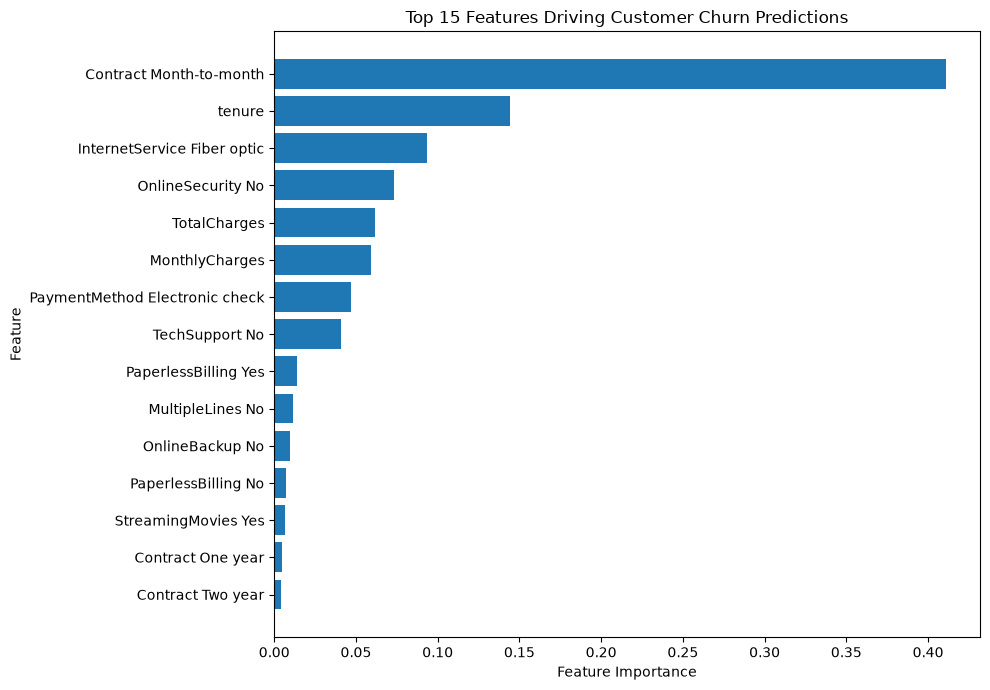

In [56]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Customer Churn Predictions")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../images/churn_risk_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Churn Driver Analysis

Feature importance identifies which variables contribute most strongly to the final model's predictions, while exploratory data analysis provides context about how these variables are associated with observed churn behavior.

Combining both perspectives provides a more business-relevant interpretation of the model and helps identify customer segments that may benefit from targeted retention strategies.

In [57]:
for column in [
    "InternetService",
    "OnlineSecurity",
    "TechSupport"
]:
    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
    )

    print(f"\n{column}")
    print(churn_rate)


InternetService
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64

TechSupport
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64


### Key Churn Drivers

Combining exploratory data analysis with Gradient Boosting feature importance reveals several important characteristics associated with customer churn.

**1. Month-to-Month Contracts**

Month-to-month contract status was the most influential feature in the Gradient Boosting model, accounting for approximately **41.12%** of the model's built-in feature importance.

EDA also showed that customers on month-to-month contracts had a churn rate of approximately **42.71%**, while customers on two-year contracts had a churn rate of only **2.83%**.

This indicates that contract structure is one of the strongest indicators of churn risk.

**2. Short Customer Tenure**

Tenure was the second most important predictive feature.

Customers who churned had an average tenure of approximately **17.98 months**, compared with **37.57 months** among customers who remained.

This suggests that customers earlier in their lifecycle represent an important retention segment.

**3. Fiber Optic Internet Service**

Fiber Optic Internet was the third most important model feature.

Fiber Optic customers showed an observed churn rate of approximately **41.89%**, compared with **18.96%** among DSL customers.

This identifies Fiber Optic customers as an important segment for further investigation and targeted retention analysis.

**4. Online Security**

Customers without Online Security showed a churn rate of approximately **41.77%**, compared with **14.61%** among customers with Online Security.

The absence of Online Security was also one of the strongest features in the final model.

**5. Monthly Charges**

Monthly Charges were among the most influential numeric predictors.

Customers who churned had average Monthly Charges of approximately **74.44**, compared with **61.27** among non-churners.

This suggests that pricing and perceived value may be important areas for further business investigation.

**6. Payment Method**

Customers using Electronic Check showed a churn rate of approximately **45.29%**, and Electronic Check was also identified as an important predictive feature.

This customer segment may warrant targeted retention analysis.

**7. Technical Support**

Customers without Tech Support showed a churn rate of approximately **41.64%**, compared with **15.17%** among customers with Tech Support.

The absence of Tech Support was also among the model's most important predictors.

## Business Recommendations

Based on the exploratory analysis, machine learning results, and model interpretation, the following retention strategies are recommended.

### 1. Prioritize Month-to-Month Customers

Month-to-month contract status was the strongest predictive feature, and these customers showed a churn rate of approximately **42.71%**.

**Recommendation:** Develop targeted campaigns encouraging high-risk month-to-month customers to move to longer-term contracts through loyalty benefits, discounts, or bundled services.

### 2. Strengthen Early-Tenure Retention

Customers who churned had substantially shorter average tenure (**17.98 months**) than customers who remained (**37.57 months**).

**Recommendation:** Introduce proactive onboarding and retention programs during the early customer lifecycle. High-risk newer customers identified by the churn model should receive additional engagement before they disengage.

### 3. Investigate the Fiber Optic Customer Experience

Fiber Optic customers showed an observed churn rate of approximately **41.89%**, considerably higher than the **18.96%** observed among DSL customers.

**Recommendation:** Investigate potential drivers within the Fiber Optic segment, including pricing, service quality, reliability, customer expectations, and support interactions. The current analysis identifies an association but does not establish that Fiber Optic service itself causes churn.

### 4. Promote Security and Support Services

Customers without Online Security or Tech Support showed churn rates above **41%**, compared with approximately **15%** among customers who had these services.

**Recommendation:** Evaluate targeted service bundles that make Online Security and Tech Support more accessible to high-risk customers. Further analysis should determine whether these services directly improve retention or primarily identify more engaged customer segments.

### 5. Review Pricing and Customer Value

Churned customers had higher average Monthly Charges (**74.44**) than non-churners (**61.27**).

**Recommendation:** Identify high-charge customers with elevated predicted churn probability and review whether pricing, service bundles, or loyalty incentives could improve perceived value.

### 6. Investigate Electronic Check Customers

Customers paying by Electronic Check showed an observed churn rate of approximately **45.29%**, and payment method was also an important predictive feature.

**Recommendation:** Investigate whether Electronic Check is associated with differences in customer profile, billing experience, or payment friction. Where appropriate, encourage convenient automatic payment options.

### 7. Use Churn Probability for Targeted Retention

Rather than applying the same retention strategy to every customer, the final Gradient Boosting model can be used to prioritize customers based on predicted churn risk.

At the selected classification threshold of **0.30**, the final model identifies approximately **76.20% of actual churners** in the held-out test dataset.

**Recommendation:** Use predicted churn probabilities to create prioritized retention lists, focusing intervention resources on customers with the highest predicted risk while considering customer value and intervention cost.

## Customer Churn Risk Segmentation

The final model produces a churn probability for each customer rather than only a binary churn prediction.

To make these probabilities more actionable for retention planning, customers are segmented into four churn-risk categories:

- **Low Risk:** Probability below 0.20
- **Moderate Risk:** Probability from 0.20 to below 0.30
- **High Risk:** Probability from 0.30 to below 0.60
- **Very High Risk:** Probability of 0.60 or above

The selected operational churn threshold of **0.30** therefore separates lower-risk customers from customers who may warrant retention attention.

Risk segmentation enables the business to prioritize retention resources according to predicted customer risk rather than treating all customers identically.

In [58]:
risk_segments = pd.cut(
    y_pred_gb_tuned_proba,
    bins=[0.00, 0.20, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],
    include_lowest=True
)

risk_segment_df = pd.DataFrame({
    "Churn_Probability": y_pred_gb_tuned_proba,
    "Risk_Segment": risk_segments,
    "Actual_Churn": y_test.to_numpy()
})

risk_segment_df.head(10)

,Churn_Probability,Risk_Segment,Actual_Churn
0,0.043094,Low Risk,0
1,0.782352,Very High Risk,0
2,0.058516,Low Risk,0
3,0.349593,High Risk,0
4,0.038416,Low Risk,0
5,0.554022,High Risk,0
6,0.432322,High Risk,0
7,0.107358,Low Risk,0
8,0.023626,Low Risk,0
9,0.350196,High Risk,1


In [59]:
risk_segment_summary = (
    risk_segment_df
    .groupby(
        "Risk_Segment",
        observed=True
    )
    .agg(
        Customers=("Actual_Churn", "size"),
        Actual_Churners=("Actual_Churn", "sum"),
        Average_Churn_Probability=("Churn_Probability", "mean")
    )
    .reset_index()
)

risk_segment_summary["Actual_Churn_Rate"] = (
    risk_segment_summary["Actual_Churners"]
    / risk_segment_summary["Customers"]
    * 100
)

risk_segment_summary[
    "Average_Churn_Probability"
] *= 100

risk_segment_summary.round(2)

,Risk_Segment,Customers,Actual_Churners,Average_Churn_Probability,Actual_Churn_Rate
0,Low Risk,754,60,7.76,7.96
1,Moderate Risk,129,29,25.02,22.48
2,High Risk,349,154,44.56,44.13
3,Very High Risk,177,131,72.47,74.01


### Risk Segmentation Results

The final Gradient Boosting model successfully separates customers into distinct churn-risk groups.

- **Low Risk:** 754 customers with an observed churn rate of **7.96%**
- **Moderate Risk:** 129 customers with an observed churn rate of **22.48%**
- **High Risk:** 349 customers with an observed churn rate of **44.13%**
- **Very High Risk:** 177 customers with an observed churn rate of **74.01%**

Observed churn increases consistently across each risk segment, demonstrating that the model can effectively rank customers according to churn risk.

The Very High Risk segment has an observed churn rate exceeding **74%**, compared with approximately **8%** among Low Risk customers.

This segmentation provides a practical framework for prioritizing retention activity. Rather than treating all customers predicted to churn equally, retention resources can be allocated according to predicted risk and the expected value of intervention.

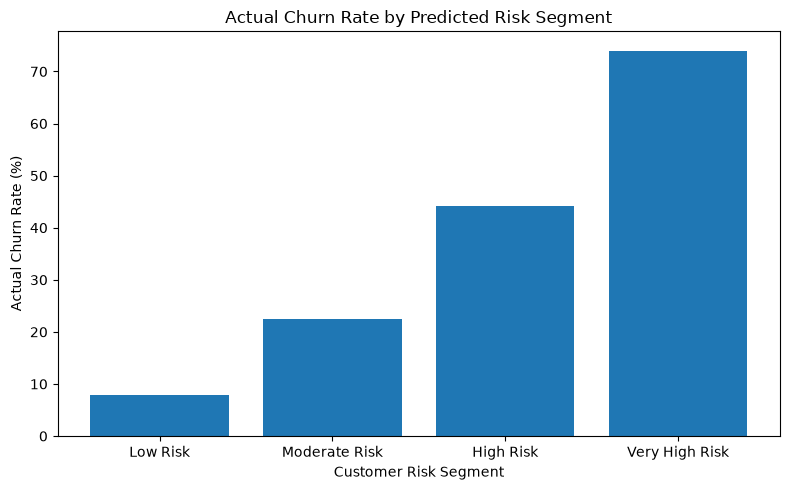

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_segment_summary["Risk_Segment"],
    risk_segment_summary["Actual_Churn_Rate"]
)

plt.xlabel("Customer Risk Segment")
plt.ylabel("Actual Churn Rate (%)")
plt.title("Actual Churn Rate by Predicted Risk Segment")


plt.tight_layout()

plt.savefig(
    "../images/churn_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Risk Segmentation Interpretation

The observed churn rate increases consistently across the predicted customer risk segments.

Customers classified as **Low Risk** have an observed churn rate of only **7.96%**, while customers classified as **Very High Risk** have an observed churn rate of **74.01%**.

The **High Risk** and **Very High Risk** segments contain customers with substantially elevated churn rates of **44.13%** and **74.01%**, respectively.

This clear separation demonstrates that the final model can be used not only to predict churn but also to prioritize customers according to their relative churn risk.

From a business perspective, this enables differentiated retention strategies, with more intensive interventions focused on customers in the highest-risk segments and lower-cost engagement strategies applied to moderate-risk customers.

## Project Conclusion

This project developed an end-to-end machine learning solution for identifying customers at risk of churn and translating model predictions into actionable retention insights.

### Key Analytical Findings

Exploratory data analysis identified several customer characteristics strongly associated with churn:

- Customers on **month-to-month contracts** showed a churn rate of approximately **42.71%**, compared with only **2.83%** among customers on two-year contracts.
- Churned customers had substantially shorter average tenure (**17.98 months**) than non-churners (**37.57 months**).
- Fiber Optic customers showed an observed churn rate of approximately **41.89%**.
- Customers without Online Security or Tech Support showed churn rates above **41%**.
- Customers using Electronic Check had an observed churn rate of approximately **45.29%**.
- Churned customers had higher average Monthly Charges (**74.44**) than customers who remained (**61.27**).

### Machine Learning Results

Four baseline classification models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Logistic Regression and Gradient Boosting emerged as the strongest baseline candidates.

Gradient Boosting was subsequently optimized using hyperparameter tuning with **Stratified 5-Fold Cross-Validation**. The tuned model achieved a held-out test ROC-AUC of **84.73%**.

Because identifying actual churners was an important business objective, classification threshold optimization was also performed using cross-validated training predictions.

A threshold of **0.30** was selected rather than the default 0.50 threshold.

### Final Model Performance

The final **Tuned Gradient Boosting Classifier at a 0.30 classification threshold** achieved:

- **Accuracy:** 76.58%
- **Precision:** 54.18%
- **Recall:** 76.20%
- **F1-Score:** 63.33%
- **ROC-AUC:** 84.73%

The final model correctly identified **285 of the 374 actual churners** in the held-out test dataset while missing 89 churners.

Compared with the original baseline Gradient Boosting model at the default threshold, the final operating strategy reduced False Negatives from **181 to 89**.

### Model Interpretation

Feature importance analysis identified **Month-to-month Contract** as the strongest predictive feature, followed by:

- Tenure
- Fiber Optic Internet Service
- Absence of Online Security
- Total Charges
- Monthly Charges
- Electronic Check payment
- Absence of Tech Support

These model findings were broadly consistent with patterns observed during exploratory data analysis.

### Customer Risk Segmentation

Predicted churn probabilities were converted into four operational customer risk segments.

Observed churn rates increased substantially across the segments:

- **Low Risk:** 7.96%
- **Moderate Risk:** 22.48%
- **High Risk:** 44.13%
- **Very High Risk:** 74.01%

The High and Very High Risk groups contained **526 of the 1,409 test customers (37.3%)**, while capturing **285 of the 374 actual churners (76.2%)**.

This demonstrates how the model can help retention teams concentrate resources on a smaller, higher-risk portion of the customer base.

### Business Impact

The analysis suggests that retention efforts should prioritize high-risk customers, particularly those with month-to-month contracts, shorter tenure, higher monthly charges, Fiber Optic service, Electronic Check payments, and limited support or security services.

Rather than treating all customers equally, predicted churn probabilities can support a tiered retention strategy in which intervention intensity is aligned with customer risk.

The project demonstrates how exploratory analysis, machine learning, model interpretation, and business decision-making can be integrated into an end-to-end customer churn analytics workflow.

### Limitations and Next Steps

The relationships identified in this analysis are predictive associations and should not be interpreted as causal effects.

Future work could incorporate customer lifetime value, retention campaign costs, intervention response data, and additional behavioral variables to optimize retention decisions based on expected financial impact rather than churn probability alone.

## Model Export for Streamlit

The fitted preprocessing pipeline and final Tuned Gradient Boosting model are exported so they can be reused by the Streamlit prediction application.

In [62]:
import joblib

joblib.dump(
    preprocessor,
    "../models/preprocessor.joblib"
)

joblib.dump(
    best_gb,
    "../models/gradient_boosting_churn_model.joblib"
)

print("Preprocessor and final model saved successfully.")

Preprocessor and final model saved successfully.
